Found 20 run folders


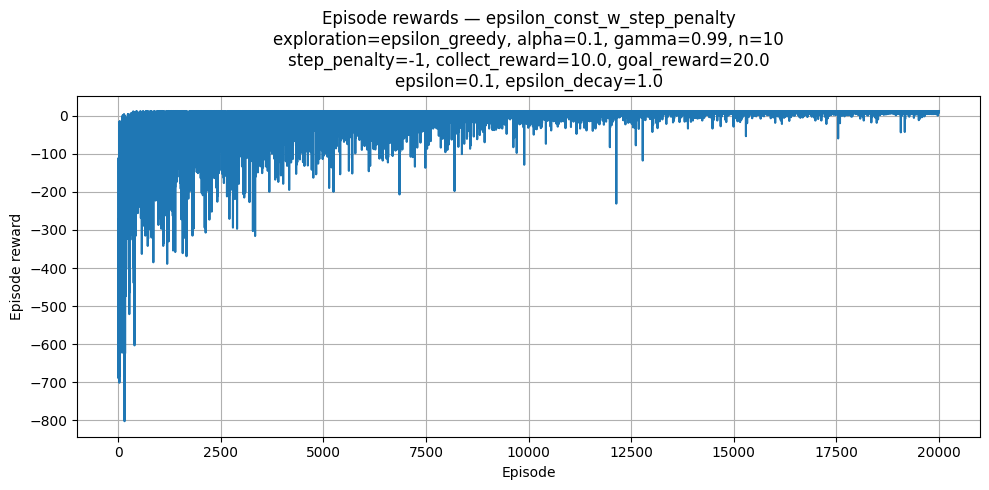

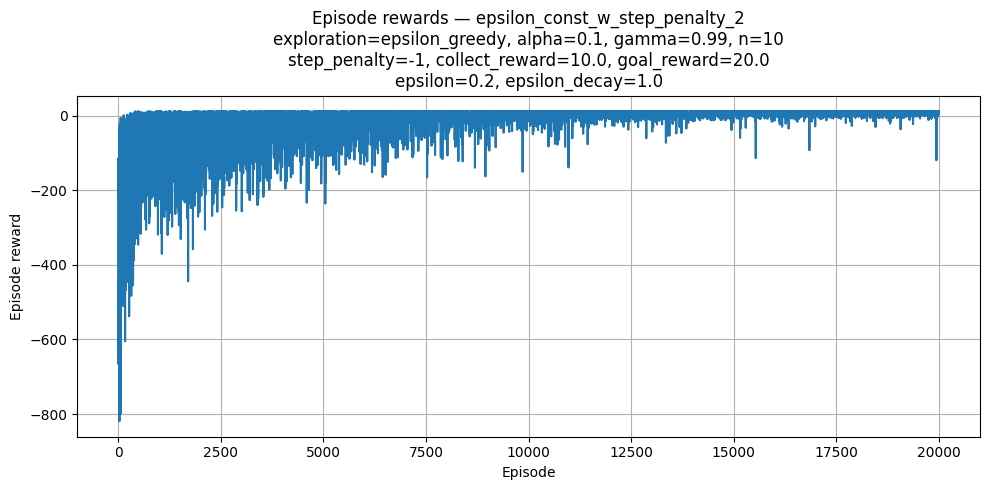

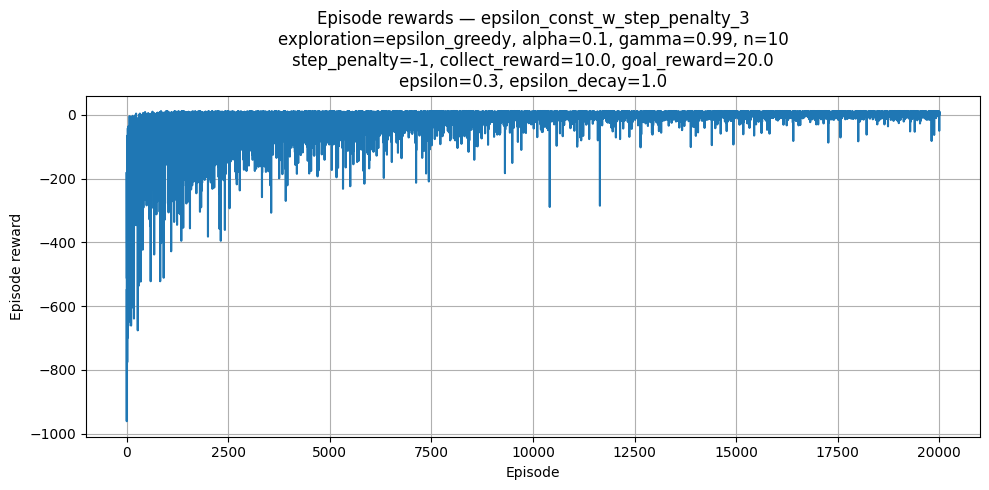

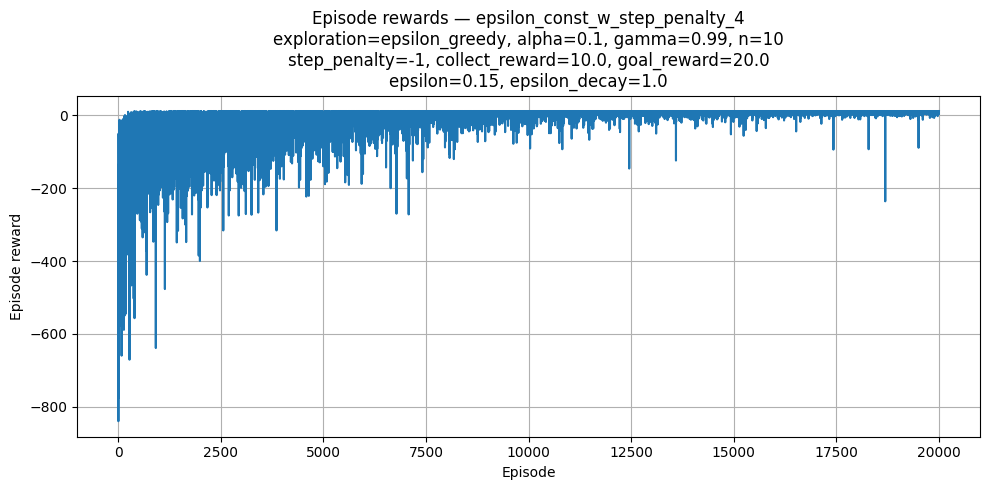

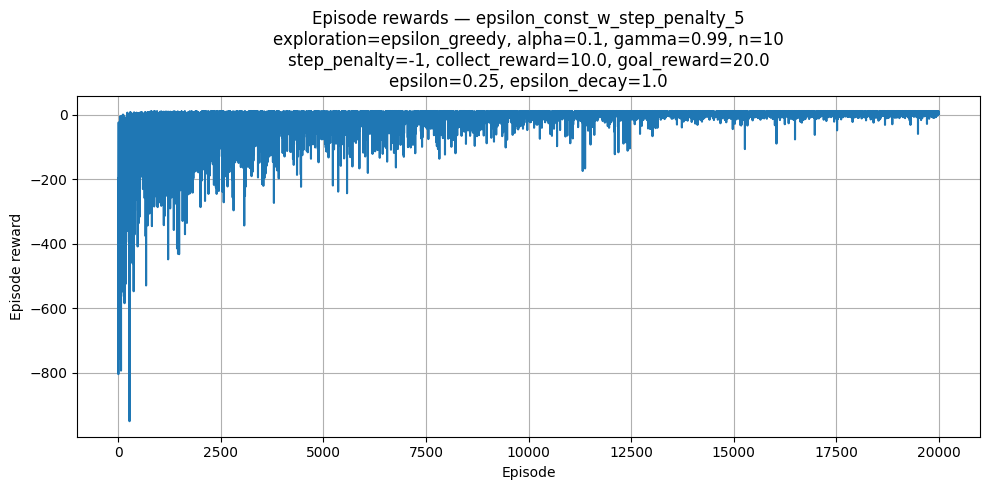

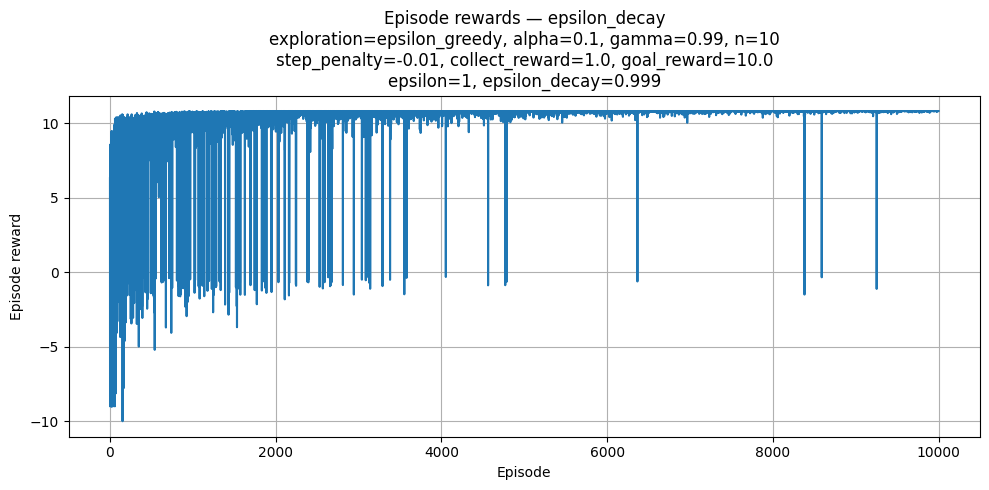

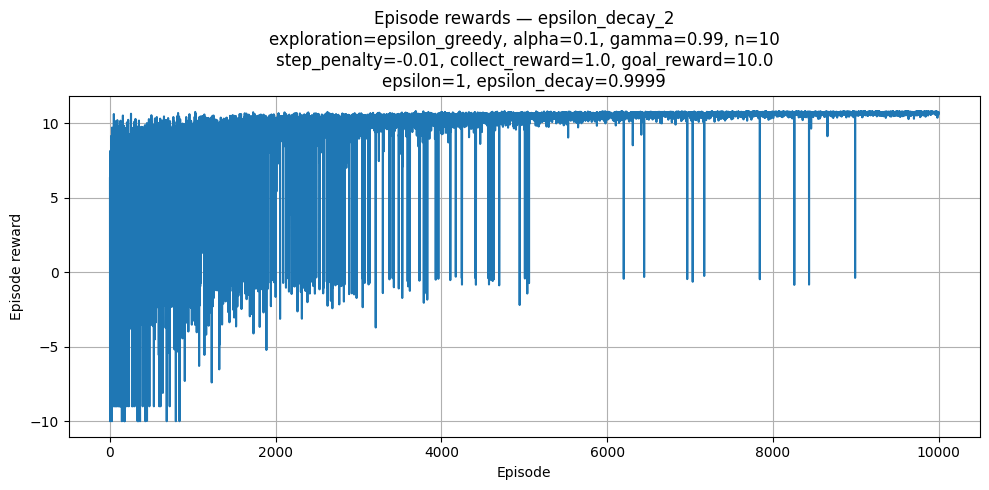

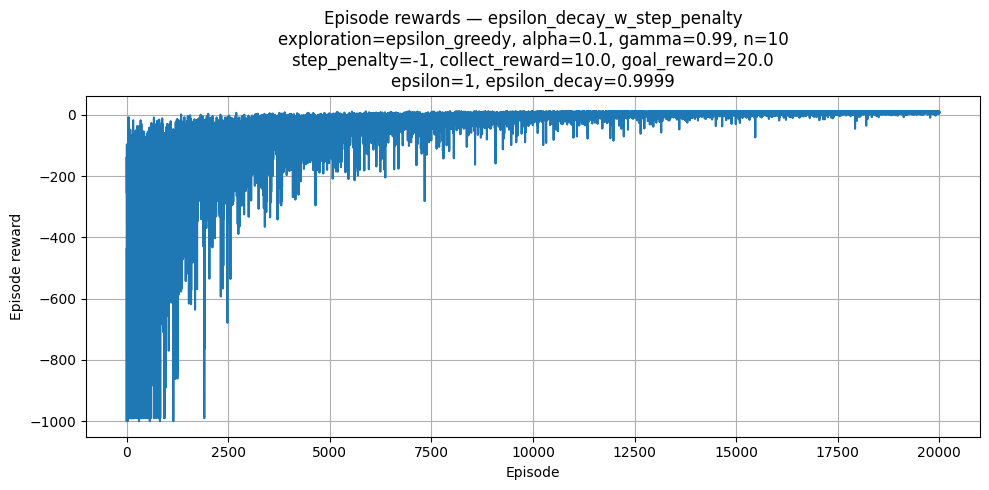

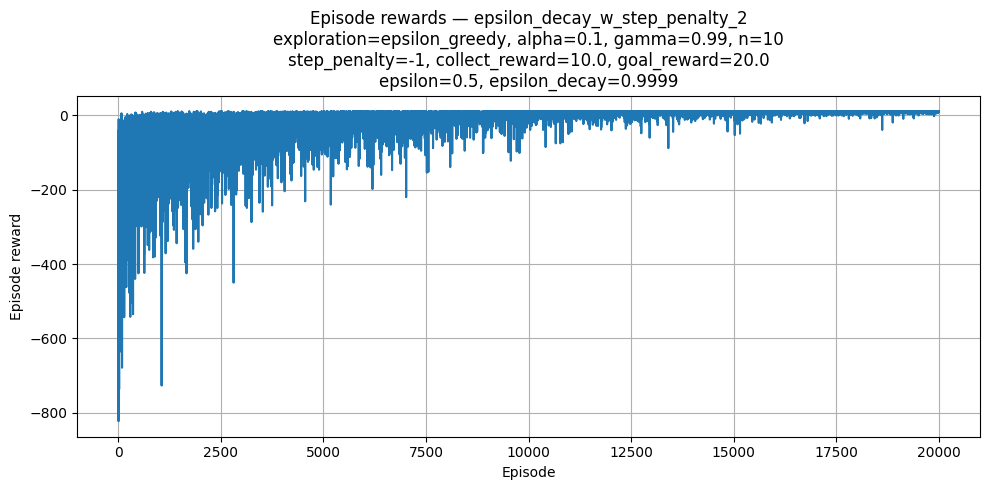

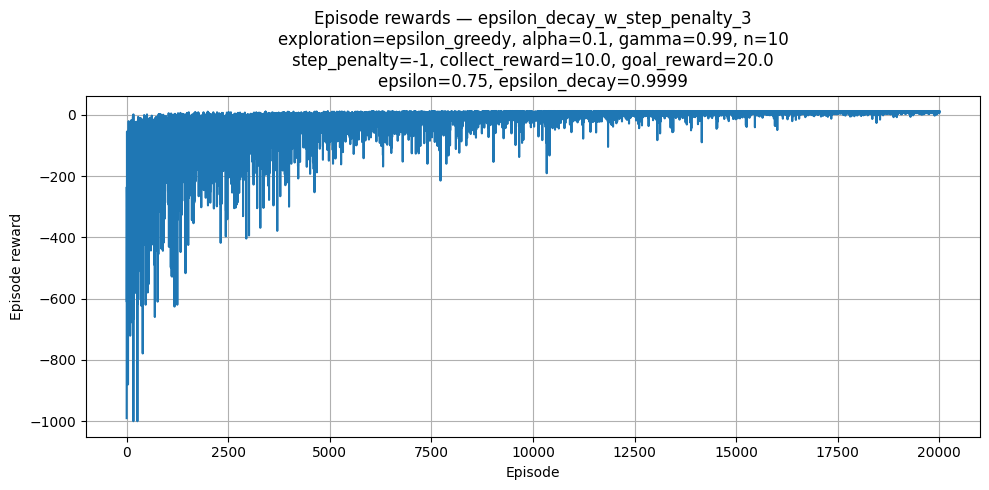

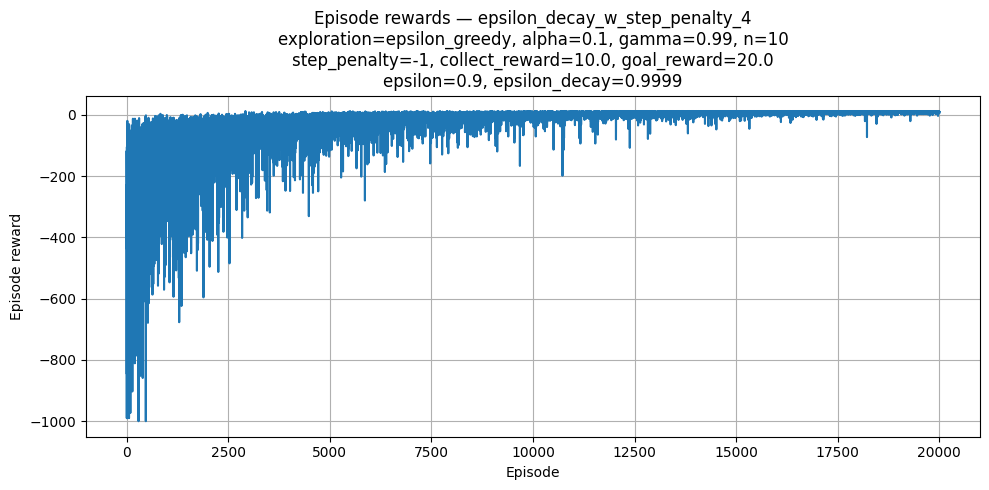

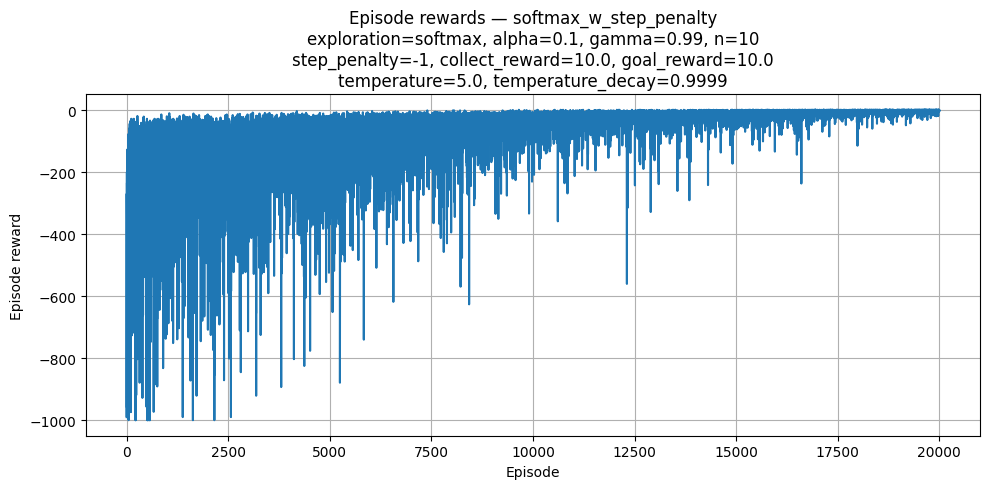

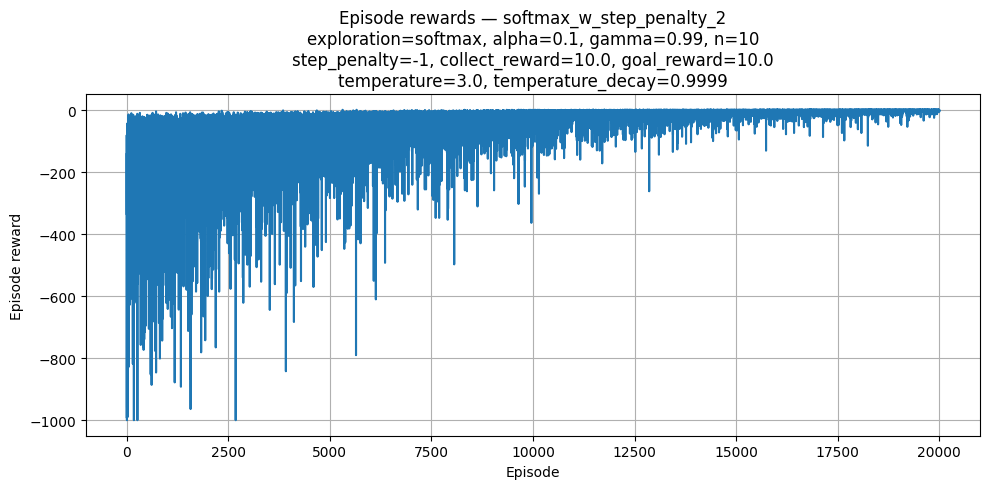

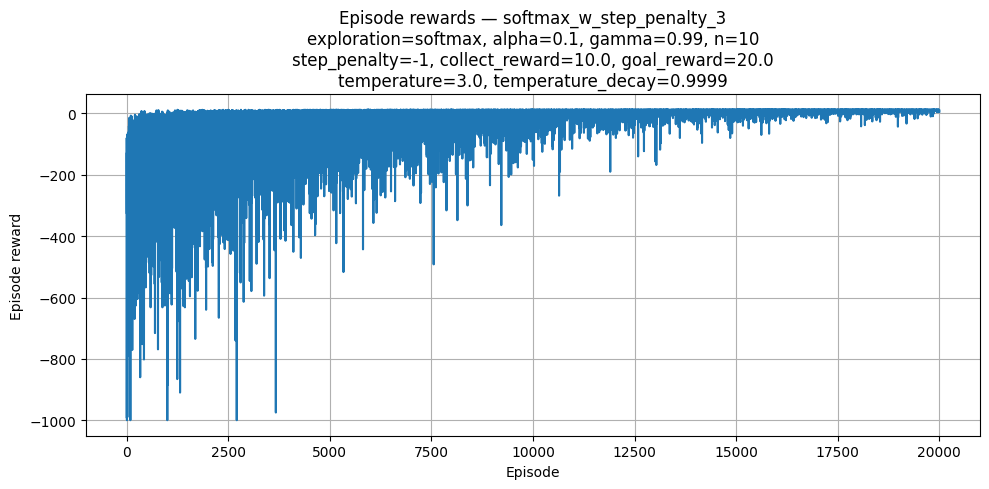

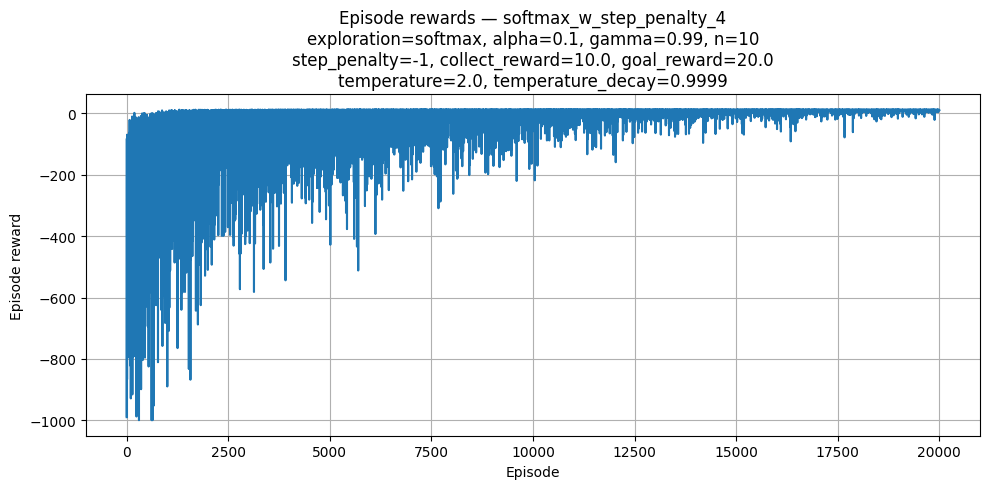

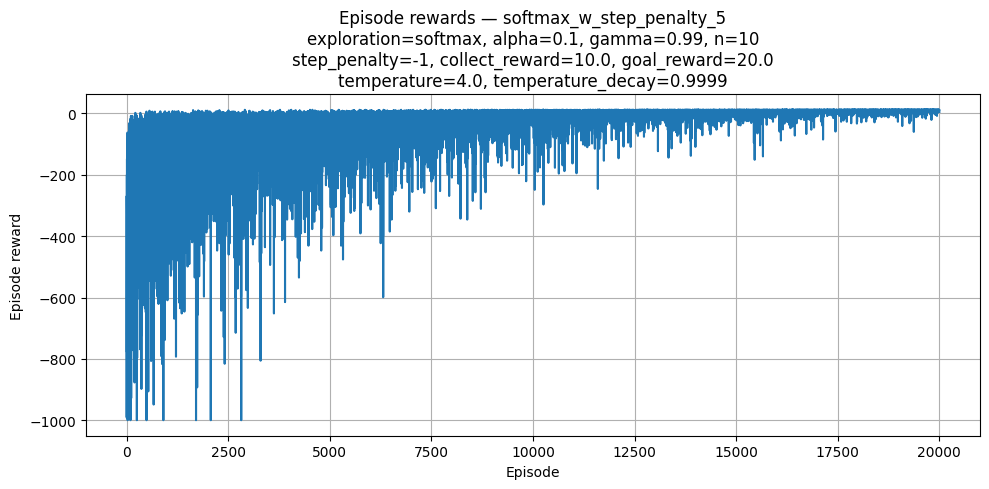

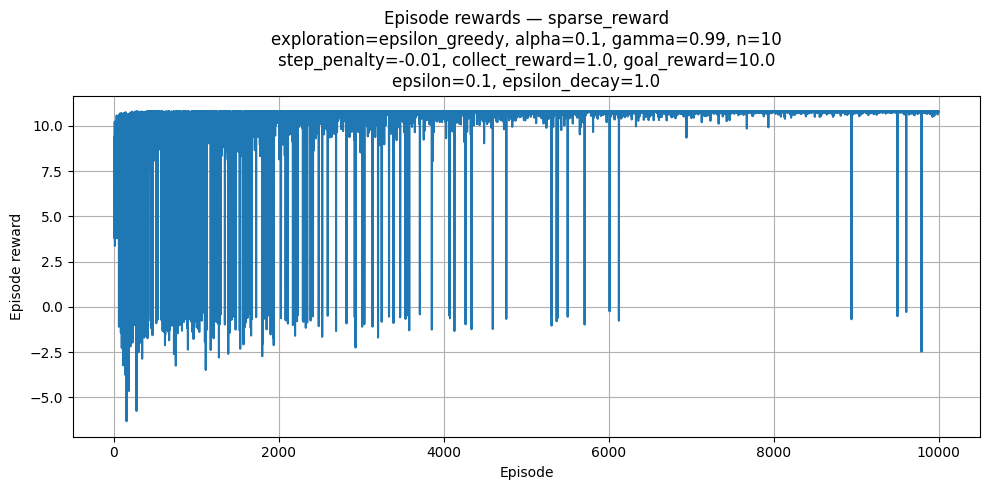

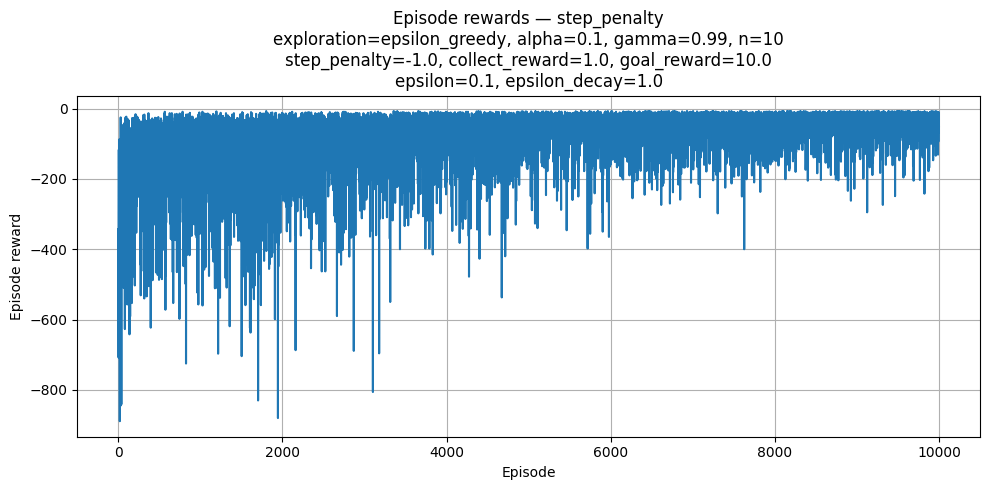

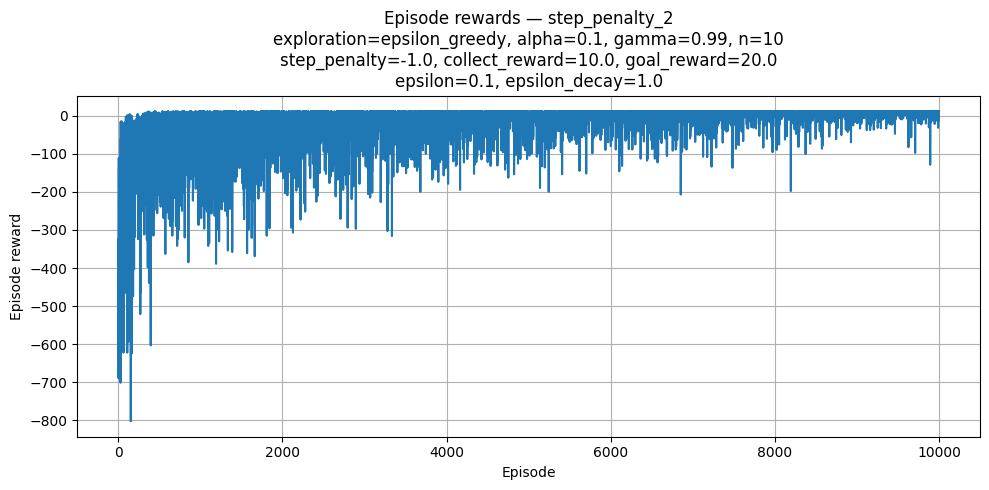

Skip test1: train_logs.json not found


In [40]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml

runs_dir = Path("../runs")


def load_yaml_safe(path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def load_json_safe(path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def infer_exploration(agent_cfg):
    if agent_cfg is None:
        return "unknown"

    if "exploration" in agent_cfg:
        return agent_cfg["exploration"]

    if "temperature" in agent_cfg:
        return "softmax"

    return "epsilon_greedy"


run_dirs = sorted([p for p in runs_dir.iterdir() if p.is_dir()])

print(f"Found {len(run_dirs)} run folders")

for run_dir in run_dirs:
    train_logs_path = run_dir / "train_logs.json"
    config_path = run_dir / "config.yaml"

    train_logs = load_json_safe(train_logs_path)
    config = load_yaml_safe(config_path)

    if train_logs is None:
        print(f"Skip {run_dir.name}: train_logs.json not found")
        continue

    episode_rewards = train_logs.get("episode_rewards", [])

    if len(episode_rewards) == 0:
        print(f"Skip {run_dir.name}: episode_rewards is empty")
        continue

    episodes = list(range(1, len(episode_rewards) + 1))

    plt.figure(figsize=(10, 5))
    plt.plot(episodes, episode_rewards)
    plt.xlabel("Episode")
    plt.ylabel("Episode reward")

    title = f"Episode rewards — {run_dir.name}"

    if config is not None:
        env_cfg = config.get("env", {})
        agent_cfg = config.get("agent", {})

        n = env_cfg.get("n", "unknown")
        step_penalty = env_cfg.get("step_penalty", "unknown")
        collect_reward = env_cfg.get("collect_reward", "unknown")
        goal_reward = env_cfg.get("goal_reward", "unknown")

        alpha = agent_cfg.get("alpha", "unknown")
        gamma = agent_cfg.get("gamma", "unknown")
        exploration = infer_exploration(agent_cfg)

        if exploration == "softmax":
            exploration_info = (
                f"temperature={agent_cfg.get('temperature', 'unknown')}, "
                f"temperature_decay={agent_cfg.get('temperature_decay', 'unknown')}"
            )
        else:
            exploration_info = (
                f"epsilon={agent_cfg.get('epsilon', 'unknown')}, "
                f"epsilon_decay={agent_cfg.get('epsilon_decay', 'unknown')}"
            )

        title += (
            f"\nexploration={exploration}, alpha={alpha}, gamma={gamma}, n={n}"
            f"\nstep_penalty={step_penalty}, collect_reward={collect_reward}, goal_reward={goal_reward}"
            f"\n{exploration_info}"
        )

    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Found 20 run folders


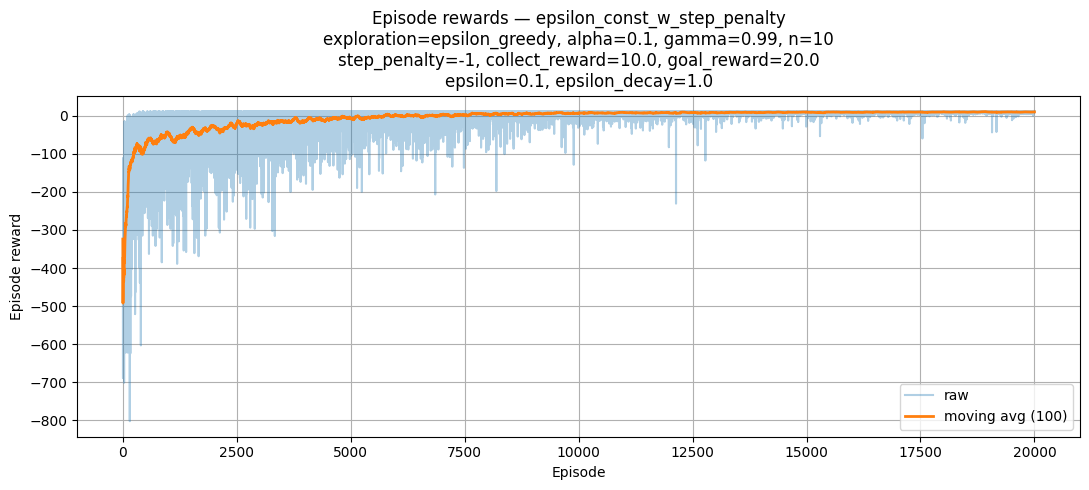

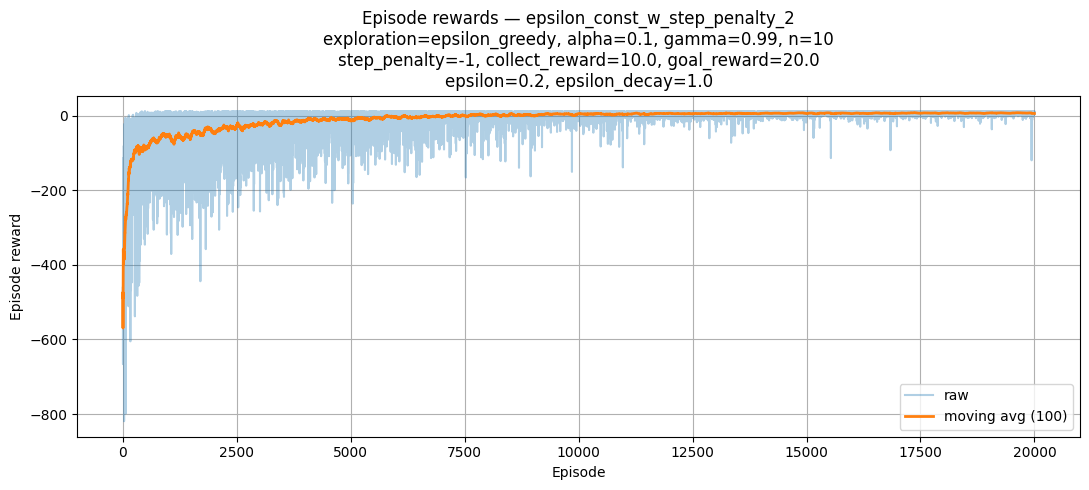

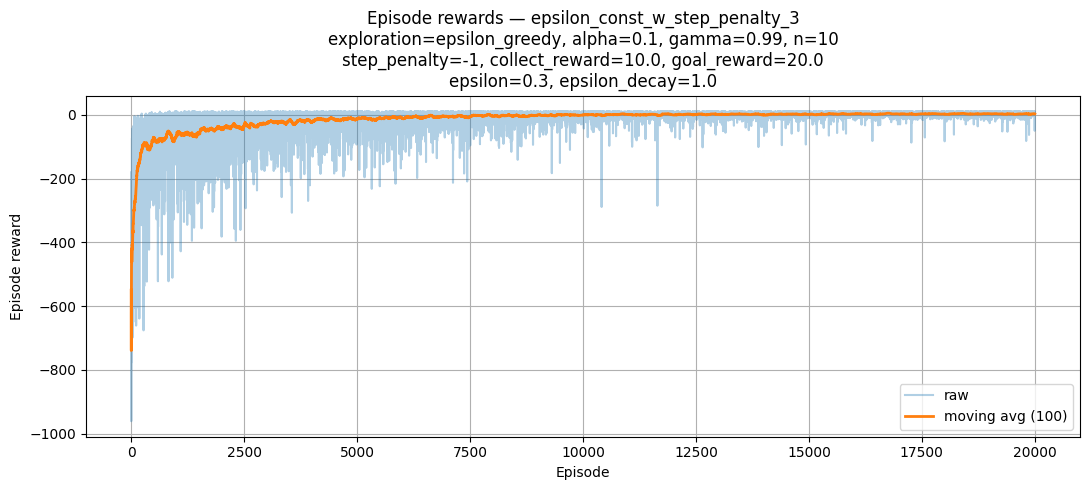

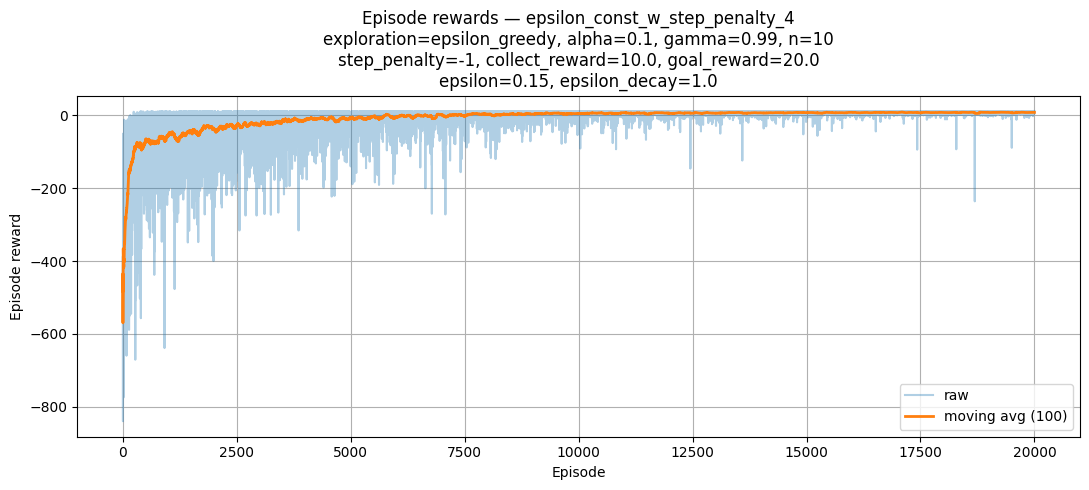

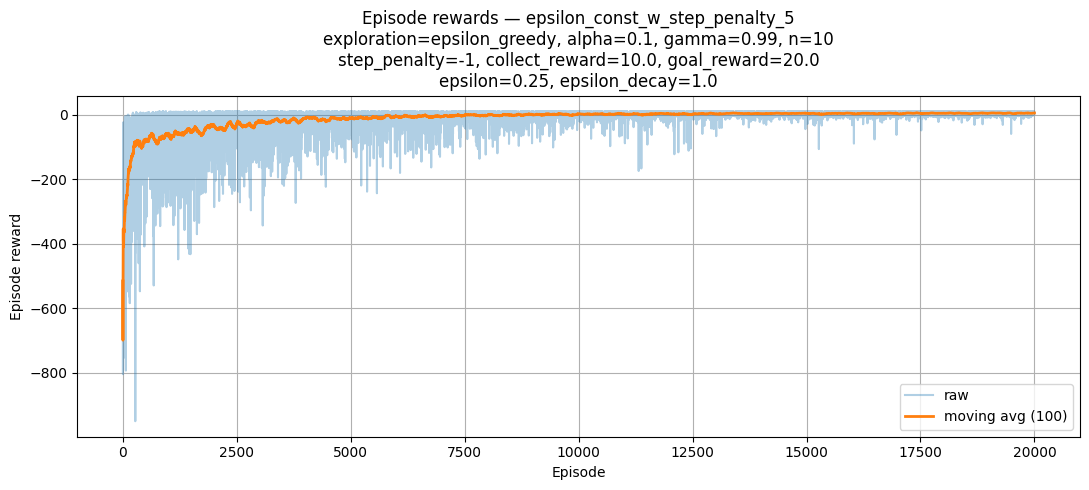

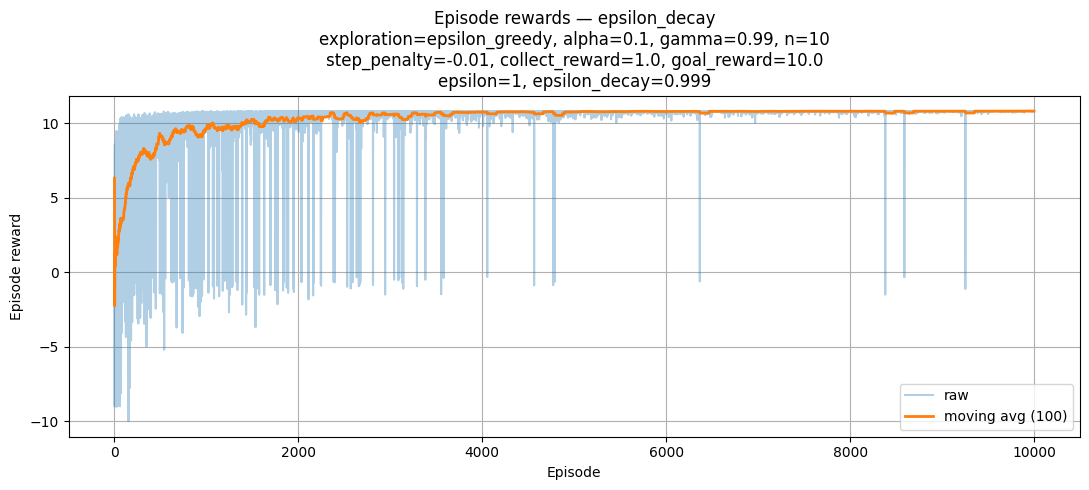

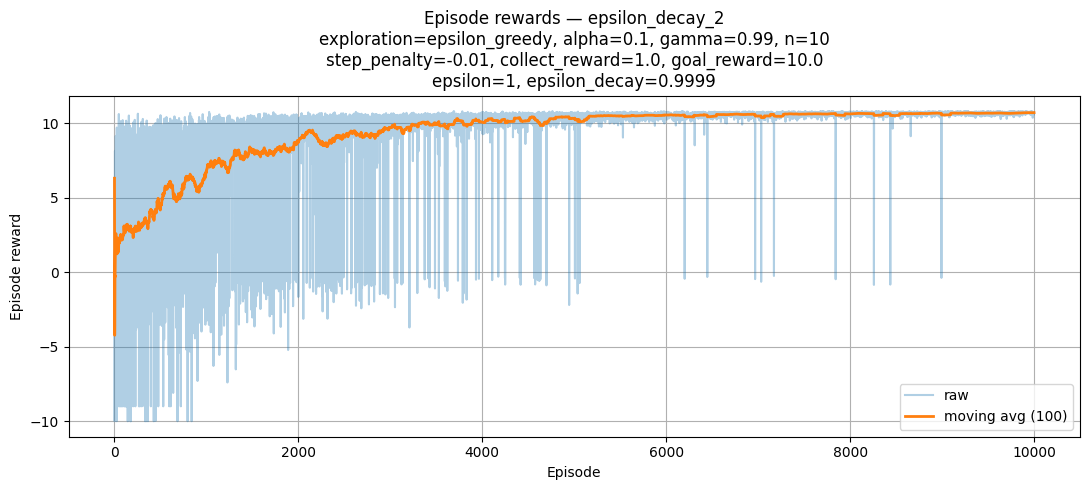

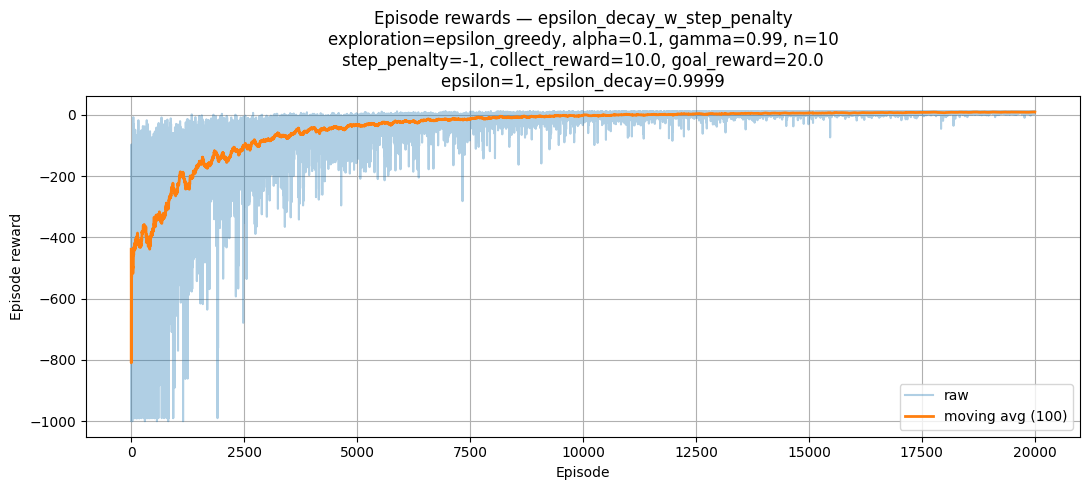

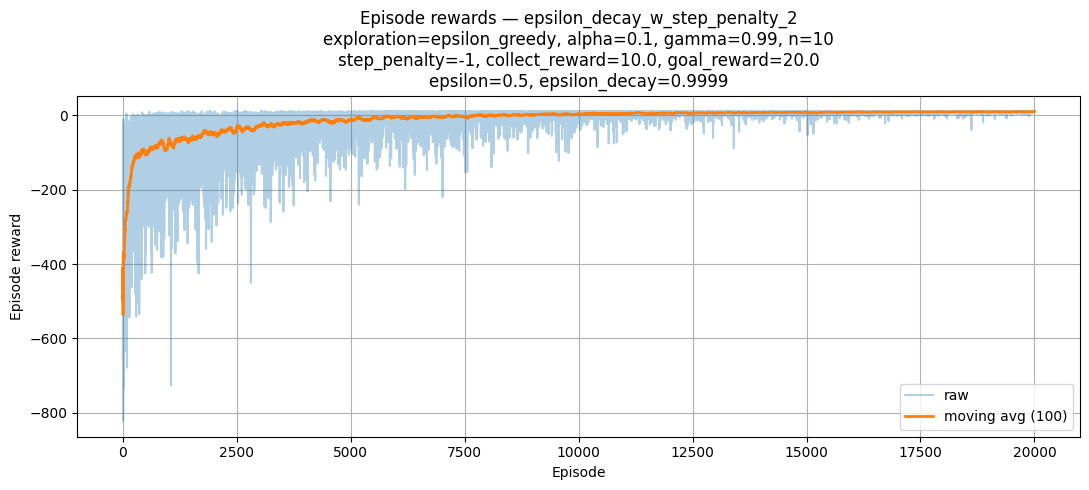

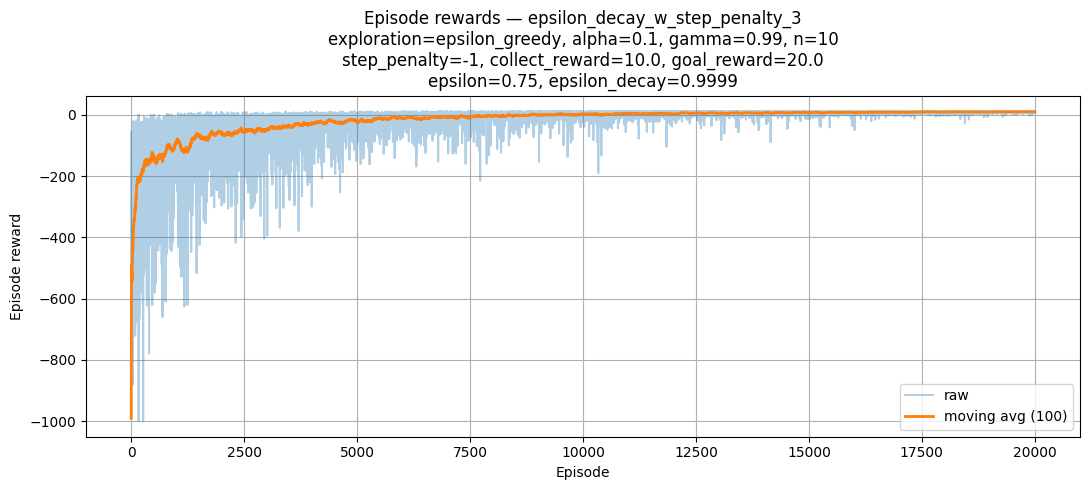

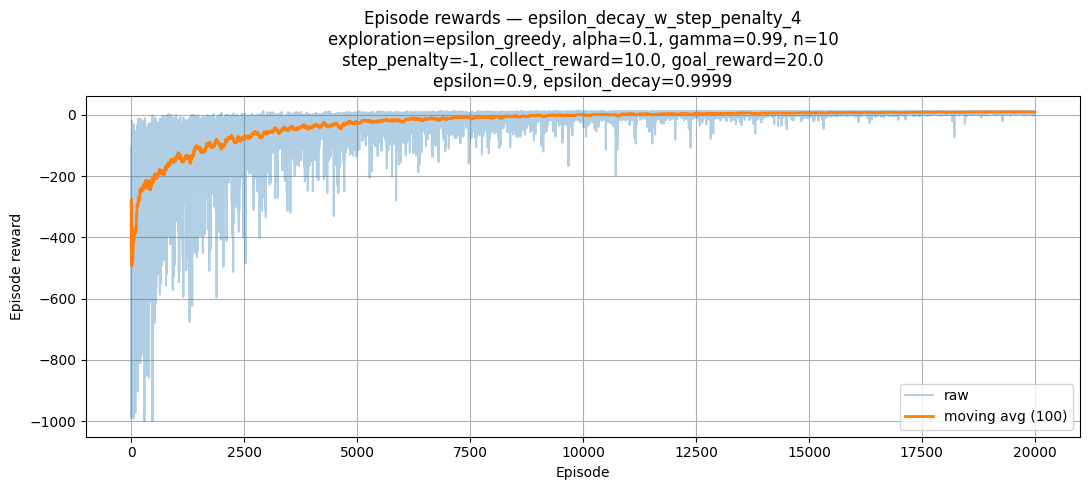

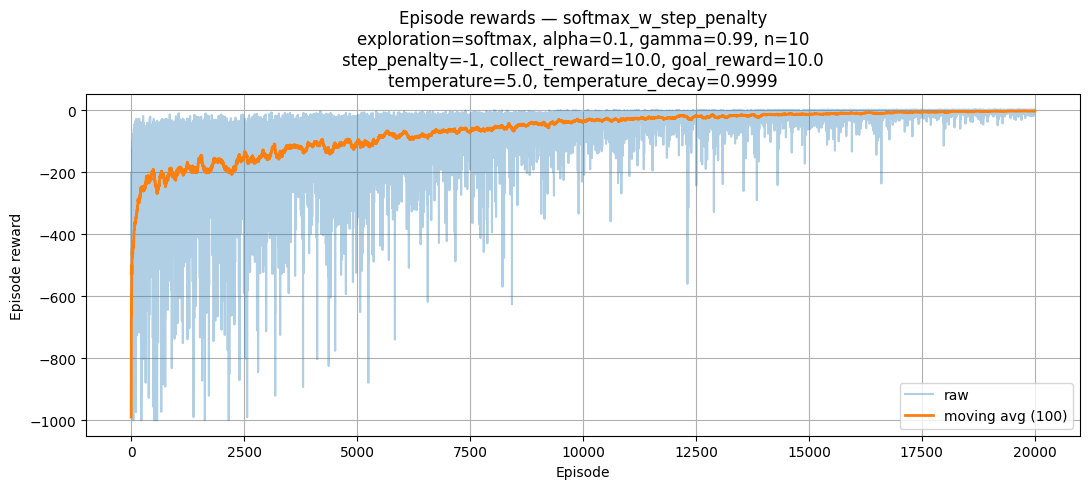

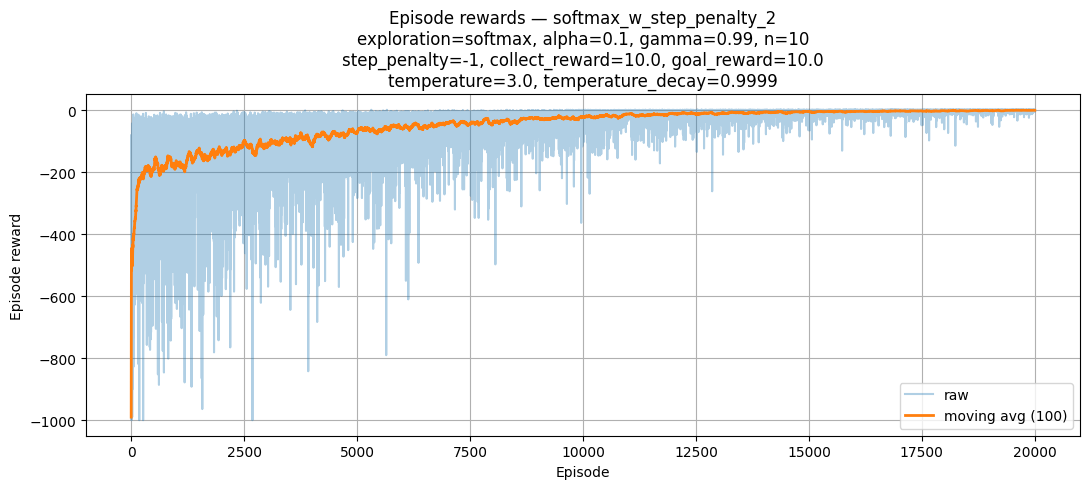

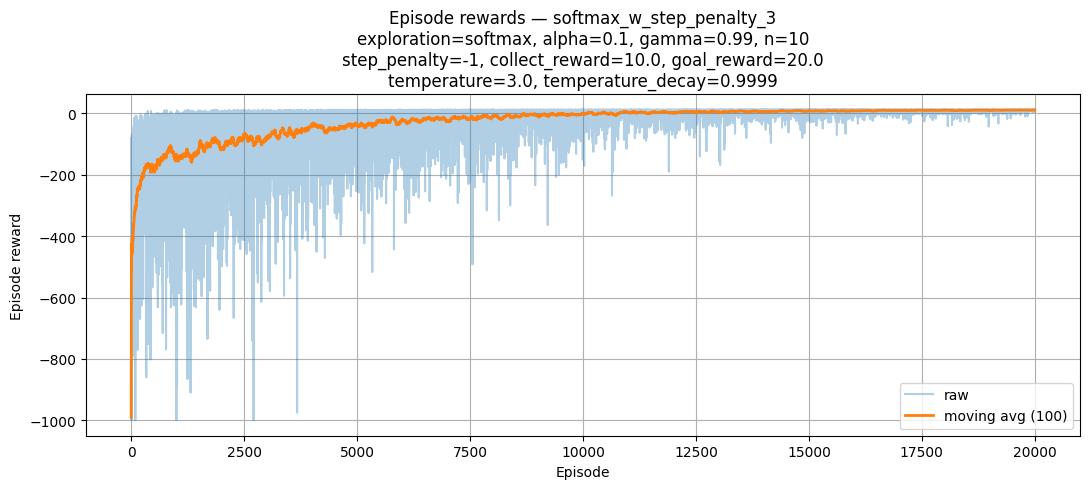

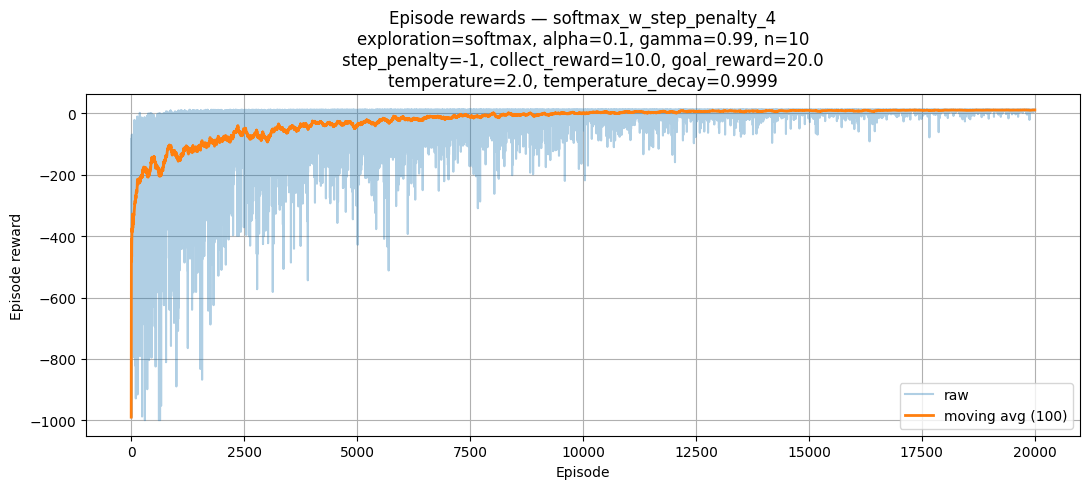

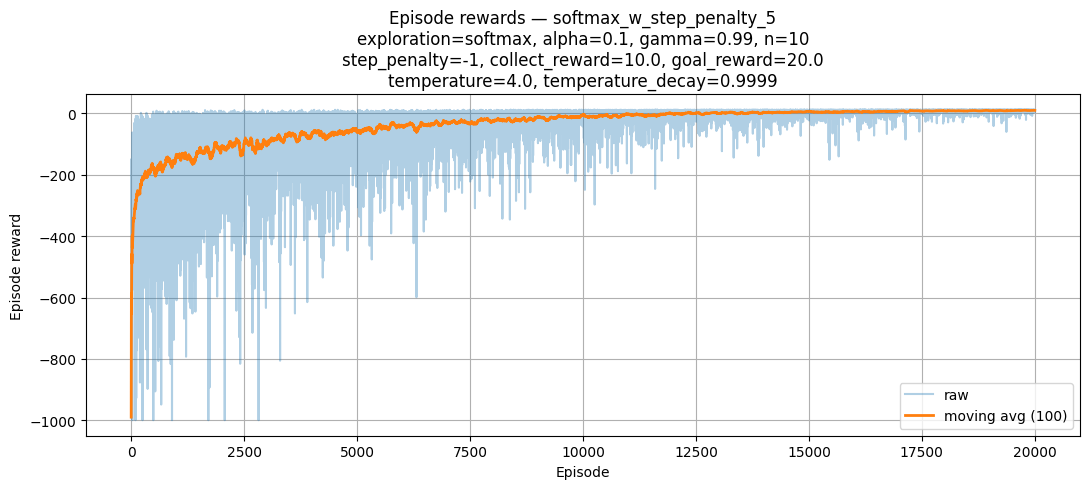

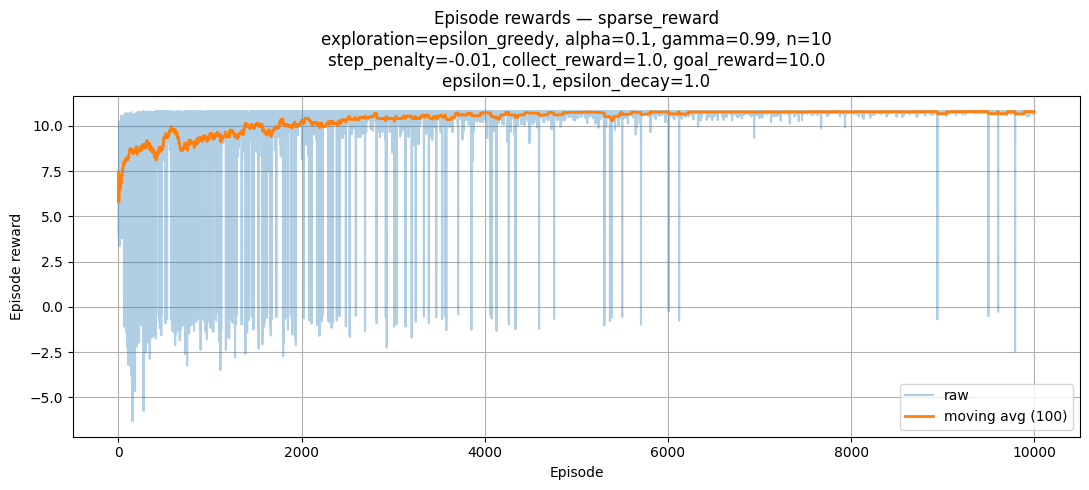

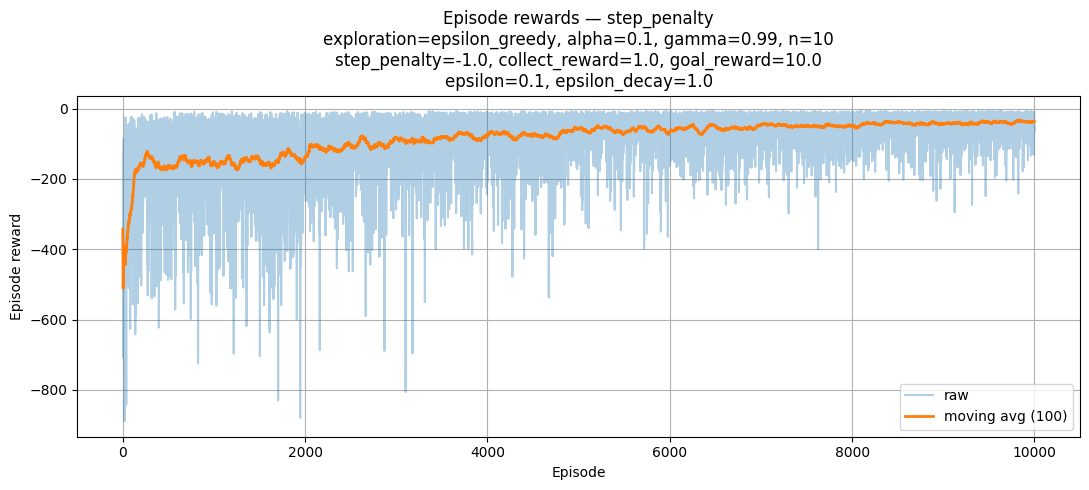

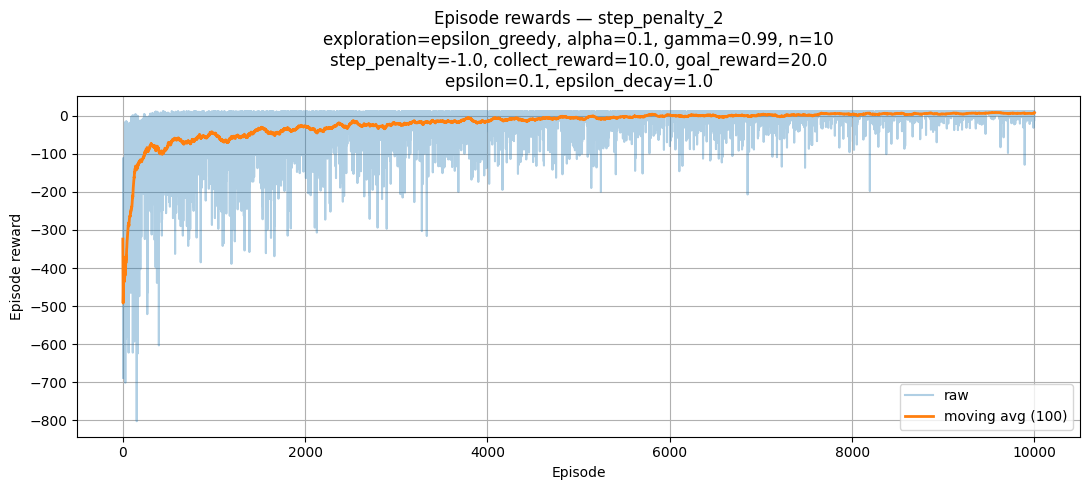

Skip test1: train_logs.json not found


In [41]:
runs_dir = Path("../runs")


def load_yaml_safe(path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def load_json_safe(path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def infer_exploration(agent_cfg):
    if agent_cfg is None:
        return "unknown"

    if "exploration" in agent_cfg:
        return agent_cfg["exploration"]

    if "temperature" in agent_cfg:
        return "softmax"

    return "epsilon_greedy"


def moving_average(values, window=100):
    return pd.Series(values, dtype=float).rolling(window=window, min_periods=1).mean()


run_dirs = sorted([p for p in runs_dir.iterdir() if p.is_dir()])

print(f"Found {len(run_dirs)} run folders")

for run_dir in run_dirs:
    train_logs_path = run_dir / "train_logs.json"
    config_path = run_dir / "config.yaml"

    train_logs = load_json_safe(train_logs_path)
    config = load_yaml_safe(config_path)

    if train_logs is None:
        print(f"Skip {run_dir.name}: train_logs.json not found")
        continue

    episode_rewards = train_logs.get("episode_rewards", [])

    if len(episode_rewards) == 0:
        print(f"Skip {run_dir.name}: episode_rewards is empty")
        continue

    episodes = list(range(1, len(episode_rewards) + 1))
    rewards_smooth = moving_average(episode_rewards, window=100)

    plt.figure(figsize=(11, 5))
    plt.plot(episodes, episode_rewards, alpha=0.35, label="raw")
    plt.plot(episodes, rewards_smooth, linewidth=2, label="moving avg (100)")

    plt.xlabel("Episode")
    plt.ylabel("Episode reward")

    title = f"Episode rewards — {run_dir.name}"

    if config is not None:
        env_cfg = config.get("env", {})
        agent_cfg = config.get("agent", {})

        n = env_cfg.get("n", "unknown")
        step_penalty = env_cfg.get("step_penalty", "unknown")
        collect_reward = env_cfg.get("collect_reward", "unknown")
        goal_reward = env_cfg.get("goal_reward", "unknown")

        alpha = agent_cfg.get("alpha", "unknown")
        gamma = agent_cfg.get("gamma", "unknown")
        exploration = infer_exploration(agent_cfg)

        if exploration == "softmax":
            exploration_info = (
                f"temperature={agent_cfg.get('temperature', 'unknown')}, "
                f"temperature_decay={agent_cfg.get('temperature_decay', 'unknown')}"
            )
        else:
            exploration_info = (
                f"epsilon={agent_cfg.get('epsilon', 'unknown')}, "
                f"epsilon_decay={agent_cfg.get('epsilon_decay', 'unknown')}"
            )

        title += (
            f"\nexploration={exploration}, alpha={alpha}, gamma={gamma}, n={n}"
            f"\nstep_penalty={step_penalty}, collect_reward={collect_reward}, goal_reward={goal_reward}"
            f"\n{exploration_info}"
        )

    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [42]:
import json
from pathlib import Path

import pandas as pd
import yaml


runs_dir = Path("../runs")


def load_yaml_safe(path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def load_json_safe(path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def infer_exploration(agent_cfg):
    if agent_cfg is None:
        return "unknown"

    if "exploration" in agent_cfg:
        return agent_cfg["exploration"]

    if "temperature" in agent_cfg:
        return "softmax"

    return "epsilon_greedy"


rows = []

run_dirs = sorted([p for p in runs_dir.iterdir() if p.is_dir()])

for run_dir in run_dirs:
    config_path = run_dir / "config.yaml"
    eval_path = run_dir / "eval_results.json"

    config = load_yaml_safe(config_path)
    eval_results = load_json_safe(eval_path)

    env_cfg = config.get("env", {}) if config is not None else {}
    agent_cfg = config.get("agent", {}) if config is not None else {}
    train_cfg = config.get("train", {}) if config is not None else {}

    exploration = infer_exploration(agent_cfg)

    row = {
        "run_name": run_dir.name,

        "episodes": train_cfg.get("n_episodes"),
        "max_steps": env_cfg.get("max_steps"),
        "step_penalty": env_cfg.get("step_penalty"),
        "collect_reward": env_cfg.get("collect_reward"),
        "goal_reward": env_cfg.get("goal_reward"),

        "exploration": exploration,
        "epsilon": agent_cfg.get("epsilon"),
        "epsilon_decay": agent_cfg.get("epsilon_decay"),
        "temperature": agent_cfg.get("temperature"),
        "temperature_decay": agent_cfg.get("temperature_decay"),

        "success_rate": None,
        "avg_episode_length": None,
    }

    if eval_results is not None:
        row["success_rate"] = eval_results.get("success_rate")
        row["avg_episode_length"] = eval_results.get("avg_episode_length")

    rows.append(row)


df = pd.DataFrame(rows)

df

,run_name,episodes,max_steps,step_penalty,collect_reward,goal_reward,exploration,epsilon,epsilon_decay,temperature,temperature_decay,success_rate,avg_episode_length
0,epsilon_const_w_step_penalty,20000.0,1000.0,-1.00,10.0,20.0,epsilon_greedy,0.10,1.0000,4.0,0.9999,0.918,98.576
1,epsilon_const_w_step_penalty_2,20000.0,1000.0,-1.00,10.0,20.0,epsilon_greedy,0.20,1.0000,4.0,0.9999,0.970,47.546
2,epsilon_const_w_step_penalty_3,20000.0,1000.0,-1.00,10.0,20.0,epsilon_greedy,0.30,1.0000,4.0,0.9999,0.966,51.388
3,epsilon_const_w_step_penalty_4,20000.0,1000.0,-1.00,10.0,20.0,epsilon_greedy,0.15,1.0000,4.0,0.9999,0.982,35.694
4,epsilon_const_w_step_penalty_5,20000.0,1000.0,-1.00,10.0,20.0,epsilon_greedy,0.25,1.0000,4.0,0.9999,0.972,45.496
5,epsilon_decay,10000.0,1000.0,-0.01,1.0,10.0,epsilon_greedy,1.00,0.9990,NaN,NaN,0.916,100.588
6,epsilon_decay_2,10000.0,1000.0,-0.01,1.0,10.0,epsilon_greedy,1.00,0.9999,NaN,NaN,0.932,84.826
7,epsilon_decay_w_step_penalty,20000.0,1000.0,-1.00,10.0,20.0,epsilon_greedy,1.00,0.9999,NaN,NaN,0.976,41.568
8,epsilon_decay_w_step_penalty_2,20000.0,1000.0,-1.00,10.0,20.0,epsilon_greedy,0.50,0.9999,4.0,0.9999,0.963,54.428
9,epsilon_decay_w_step_penalty_3,20000.0,1000.0,-1.00,10.0,20.0,epsilon_greedy,0.75,0.9999,4.0,0.9999,0.923,93.614
